
# Регулируемый трансформер + сравнение методов МК-оптимизации гиперпараметров
**Задача:** бинарная классификация тональности (IMDB Movie Reviews)

**Методы оптимизации:** Random Search | Simulated Annealing | Bayesian Optimization (Optuna)

In [1]:
!pip install datasets optuna

import numpy as np, random, math, time, warnings
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from datasets import load_dataset
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def seed(s=42): random.seed(s); np.random.seed(s); torch.manual_seed(s)
seed()
print(f"device:{DEVICE}")

device:cuda


## 1. Данные и токенизация

In [2]:
ds = load_dataset("imdb")
MAX_LEN = 192
PAD, UNK = 0, 1

tokenize = lambda t: [w for w in ''.join(c if c.isalpha() or c==' ' else ' ' for c in t.lower()).split() if len(w)>1]
counter = Counter()
for item in  ds['train']:counter.update(tokenize(item['text']))
vocab = ['<pad>', '<unk>'] + [w for w, c in counter.most_common(18_000) if c >= 3]  
w2i = {w:i for i, w in enumerate(vocab)}
VOCAB = len(vocab)

def encode(text):
    ids = [w2i.get(t, UNK) for t in tokenize(text)[:MAX_LEN]]
    return ids + [PAD]*(MAX_LEN-len(ids))
 
class IMDBDataset(Dataset):
    def __init__(self, items):
        self.x = [encode(i['text']) for i in items]
        self.y = [i['label'] for i in items]
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return torch.tensor(self.x[i], dtype=torch.long), torch.tensor(self.y[i], dtype=torch.long)
 
rng = np.random.default_rng(42)
tp  = rng.permutation(len(ds['train'])).tolist()
 
def get_items(split, idx): return [ds[split][int(i)] for i in idx]
 
srch_tr = IMDBDataset(get_items('train', tp[:4000]))
srch_vl = IMDBDataset(get_items('train', tp[4000:5200]))
fin_tr  = IMDBDataset(get_items('train', tp[:18000]))
fin_vl  = IMDBDataset(get_items('train', tp[18000:20500]))
test_ds = IMDBDataset(get_items('test',  rng.permutation(len(ds['test'])).tolist()[:3000]))
 
print(f"Словарь: {VOCAB:,}  |  search train/val: {len(srch_tr)}/{len(srch_vl)}"
      f"  |  final train/val: {len(fin_tr)}/{len(fin_vl)}  |  test: {len(test_ds)}")
 

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Словарь: 18,002  |  search train/val: 4000/1200  |  final train/val: 18000/2500  |  test: 3000


## 2. Архитектура - Regulated Transformer


In [21]:
class RegAttention(nn.Module):
    def __init__(self, d, h, drop):
        super().__init__()
        self.h, self.dk = h, d // h
        self.qkv = nn.Linear(d, 3*d, bias=False)
        self.proj = nn.Linear(d, d)
        self.drop = nn.Dropout(drop)
        self.tau = nn.Parameter(torch.ones(h, 1, 1))

    def forward(self, x, mask=None):
        B, T, D = x.shape
        q, k, v = self.qkv(x).reshape(B, T, 3, self.h, self.dk).permute(2, 0, 3, 1, 4)
        tau = self.tau.clamp(0.1, 5.0)
        sc = (q @ k.transpose(-2, -1)) / (math.sqrt(self.dk) * tau)
        if mask is not None: sc = sc.masked_fill(mask[:,None, None, :], -1e9)
        out = self.drop(sc.softmax(-1)) @ v
        return self.proj(out.transpose(1, 2).reshape(B, T, D))


class RegBlock(nn.Module):
    def __init__(self, d, h, dff, drop):
        super().__init__()
        self.attn = RegAttention(d, h, drop)
        self.ff = nn.Sequential(nn.Linear(d, dff),
                               nn.GELU(),
                               nn.Dropout(drop),
                               nn.Linear(dff, d))
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.drop = nn.Dropout(drop)
        self.ga = nn.Parameter(torch.zeros(d))
        self.gf = nn.Parameter(torch.zeros(d))

    def forward(self, x, mask=None):
        x = x + torch.sigmoid(self.ga) * self.drop(self.attn(self.n1(x), mask))
        x = x + torch.sigmoid(self.gf) * self.drop(self.ff(self.n2(x)))
        return x

class RegTransformer(nn.Module):
    def __init__(self, d, h, L, dff, drop):
        super().__init__()
        self.emb = nn.Embedding(VOCAB, d, padding_idx=PAD)
        self.pos = nn.Embedding(MAX_LEN, d)
        self.drop = nn.Dropout(drop)
        self.blocks = nn.ModuleList([RegBlock(d, h,dff, drop) for _ in range(L)])
        self.norm = nn.LayerNorm(d)
        self.head = nn.Sequential(nn.Linear(d, d//2), nn.GELU(), nn.Dropout(drop), nn.Linear(d//2, 2))
        self.apply(lambda m: nn.init.trunc_normal_(m.weight, std=0.02)
                  if isinstance(m, (nn.Linear, nn.Embedding)) else None)
        
    def forward(self, x):
        mask = (x == PAD)
        pos = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        h = self.drop(self.emb(x) + self.pos(pos))
        for b in self.blocks: h = b(h, mask)
        h = self.norm(h)
        v = (~mask).unsqueeze(-1).float()
        return self.head((h*v).sum(1) / v.sum(1).clamp(1))
        
    def n_params(self): return sum(p.numel() for p in self.parameters() if p.requires_grad)
        

## 3. Функции обучения и оценки


In [22]:
CEL = nn.CrossEntropyLoss()
 
def make_loaders(p, tr_ds, vl_ds):
    return (DataLoader(tr_ds, p['bs'], shuffle=True,  num_workers=0, drop_last=True),
            DataLoader(vl_ds, 128,     shuffle=False, num_workers=0))
 
def build(p):
    torch.manual_seed(42)
    return RegTransformer(p['d'], p['h'], p['L'], p['d']*p['ff'], p['drop']).to(DEVICE)
 
def train_ep(model, loader, opt, sch):
    model.train()
    loss_sum = corr = n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        l = CEL(logits, yb)
        opt.zero_grad(); l.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sch.step()
        loss_sum += l.item()*len(yb)
        corr += (logits.detach().argmax(1)==yb).sum().item()
        n += len(yb)
    return loss_sum/n, corr/n
 
@torch.no_grad()
def eval_ep(model, loader):
    model.eval()
    ls = corr = n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        out = model(xb); ls += CEL(out,yb).item()*len(yb)
        corr += (out.argmax(1)==yb).sum().item(); n += len(yb)
    return ls/n, corr/n
 
def trial(p, tr_ds, vl_ds, epochs=3):
    trl, vll = make_loaders(p, tr_ds, vl_ds)
    model = build(p)
    opt = optim.AdamW(model.parameters(), lr=p['lr'], weight_decay=1e-4)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, len(trl)*epochs, eta_min=p['lr']*0.01)
    best = 0.0
    for _ in range(epochs):
        train_ep(model, trl, opt, sch)
        best = max(best, eval_ep(model, vll)[1])
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return best
 
SPACE = {
    'd':    [64, 96, 128, 192, 256],
    'h':    [2, 4, 8],
    'L':    [1, 2, 3, 4],
    'drop': [0.1, 0.15, 0.2, 0.3, 0.4],
    'lr':   [5e-5, 1e-4, 2e-4, 3e-4, 5e-4, 8e-4, 1e-3],
    'bs':   [32, 64, 128],
    'ff':   [2, 4]
}
DEFAULT = {'d':128,'h':4,'L':2,'drop':0.2,'lr':3e-4,'bs':64,'ff':4}
 
def valid(p):
    return p['d'] % p['h'] == 0
 
def rand_p():
    while True:
        p = {k: random.choice(v) for k,v in SPACE.items()}
        if valid(p): return p
 
def fix_h(p):
    if not valid(p):
        p['h'] = random.choice([hh for hh in SPACE['h'] if p['d'] % hh == 0])
    return p
 
N_ITER   = 18   # число итераций каждого метода
N_EPOCHS = 3    # число эпох на одну пробу


## 4. Random Search


In [23]:
def random_search(n_iter=N_ITER):
    hist, best, best_p = [], 0.0, None
    for i in range(n_iter):
        p = rand_p()
        sc = trial(p, srch_tr, srch_vl, N_EPOCHS)
        if sc > best: best, best_p = sc, p.copy()
        hist.append({'iter':i+1,'score':sc,'best':best,'params':p})
        print(f"  [RS {i+1:2d}/{n_iter}] acc={sc:.4f} best={best:.4f}")
    return best_p, best, hist
 
print("Random Search"); t0=time.time()
rs_best, rs_score, rs_hist = random_search()
rs_time = time.time()-t0
print(f"=> best val acc: {rs_score:.4f}  ({rs_time/60:.1f} мин)")

Random Search
  [RS  1/18] acc=0.6908 best=0.6908
  [RS  2/18] acc=0.8075 best=0.8075
  [RS  3/18] acc=0.4800 best=0.8075
  [RS  4/18] acc=0.8367 best=0.8367
  [RS  5/18] acc=0.8475 best=0.8475
  [RS  6/18] acc=0.8500 best=0.8500
  [RS  7/18] acc=0.4792 best=0.8500
  [RS  8/18] acc=0.7458 best=0.8500
  [RS  9/18] acc=0.4792 best=0.8500
  [RS 10/18] acc=0.8142 best=0.8500
  [RS 11/18] acc=0.8133 best=0.8500
  [RS 12/18] acc=0.8400 best=0.8500
  [RS 13/18] acc=0.8333 best=0.8500
  [RS 14/18] acc=0.8525 best=0.8525
  [RS 15/18] acc=0.8550 best=0.8550
  [RS 16/18] acc=0.8475 best=0.8550
  [RS 17/18] acc=0.7717 best=0.8550
  [RS 18/18] acc=0.8500 best=0.8550
=> best val acc: 0.8550  (3.4 мин)


## 5. Simulated Annealing

In [24]:
def simulated_annealing(n_iter=N_ITER, T0=0.04, alpha=0.87):
    def perturb(p):
        q = p.copy()
        k = random.choice(list(SPACE.keys()))
        q[k] = random.choice(SPACE[k])
        return fix_h(q)
 
    random.seed(7)
    cur = rand_p(); cur_sc = trial(cur, srch_tr, srch_vl, N_EPOCHS)
    best, best_sc, T = cur.copy(), cur_sc, T0
    hist = [{'iter':0,'score':cur_sc,'best':best_sc,'T':T,'accepted':True,'improved':True}]
 
    for i in range(1, n_iter+1):
        cand = perturb(cur); cand_sc = trial(cand, srch_tr, srch_vl, N_EPOCHS)
        delta = cand_sc - cur_sc
        accept = delta > 0 or random.random() < math.exp(delta/T)
        improved = cand_sc > best_sc
        if accept:   cur, cur_sc   = cand.copy(), cand_sc
        if improved: best, best_sc = cand.copy(), cand_sc
        hist.append({'iter':i,'score':cand_sc,'best':best_sc,'T':T,
                     'accepted':accept,'improved':improved})
        tag = "*** РЕКОРД" if improved else ("принято" if accept else "отклонено")
        print(f"  [SA {i:2d}/{n_iter}] acc={cand_sc:.4f} best={best_sc:.4f} T={T:.4f} {tag}")
        T *= alpha
 
    return best, best_sc, hist
 
print("\nSimulated Annealing"); t0=time.time()
sa_best, sa_score, sa_hist = simulated_annealing()
sa_time = time.time()-t0
print(f"=> best val acc: {sa_score:.4f}  ({sa_time/60:.1f} мин)")


Simulated Annealing
  [SA  1/18] acc=0.4792 best=0.5192 T=0.0400 отклонено
  [SA  2/18] acc=0.5192 best=0.5192 T=0.0348 принято
  [SA  3/18] acc=0.5192 best=0.5192 T=0.0303 принято
  [SA  4/18] acc=0.8008 best=0.8008 T=0.0263 *** РЕКОРД
  [SA  5/18] acc=0.7842 best=0.8008 T=0.0229 принято
  [SA  6/18] acc=0.7700 best=0.8008 T=0.0199 отклонено
  [SA  7/18] acc=0.7842 best=0.8008 T=0.0173 принято
  [SA  8/18] acc=0.8158 best=0.8158 T=0.0151 *** РЕКОРД
  [SA  9/18] acc=0.7842 best=0.8158 T=0.0131 отклонено
  [SA 10/18] acc=0.8158 best=0.8158 T=0.0114 принято
  [SA 11/18] acc=0.7842 best=0.8158 T=0.0099 отклонено
  [SA 12/18] acc=0.8158 best=0.8158 T=0.0086 принято
  [SA 13/18] acc=0.8392 best=0.8392 T=0.0075 *** РЕКОРД
  [SA 14/18] acc=0.8317 best=0.8392 T=0.0065 принято
  [SA 15/18] acc=0.8375 best=0.8392 T=0.0057 принято
  [SA 16/18] acc=0.7783 best=0.8392 T=0.0050 отклонено
  [SA 17/18] acc=0.8483 best=0.8483 T=0.0043 *** РЕКОРД
  [SA 18/18] acc=0.8350 best=0.8483 T=0.0037 отклонено
=

## 6. Bayesian Optimization (Optuna - TPE)

In [25]:
def bayesian_optuna(n_iter=N_ITER):
    hist, best_sc = [], 0.0
 
    def objective(trial_):
        p = {
            'd':    trial_.suggest_categorical('d', SPACE['d']),
            'h':    trial_.suggest_categorical('h', SPACE['h']),
            'L':    trial_.suggest_categorical('L', SPACE['L']),
            'drop': trial_.suggest_categorical('drop', SPACE['drop']),
            'lr':   trial_.suggest_categorical('lr', SPACE['lr']),
            'bs':   trial_.suggest_categorical('bs', SPACE['bs']),
            'ff':   trial_.suggest_categorical('ff', SPACE['ff']),
        }
        p = fix_h(p)
        sc = trial(p, srch_tr, srch_vl, N_EPOCHS)
        hist.append({'params': p.copy(), 'score': sc})
        return sc
 
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_iter, n_jobs=1)
 
    for i, h in enumerate(hist):
        best_sc = max(best_sc, h['score'])
        h.update({'iter': i+1, 'best': best_sc})
        print(f"  [BO {i+1:2d}/{n_iter}] acc={h['score']:.4f} best={best_sc:.4f}")
 
    bp = study.best_params.copy()
    bp = fix_h(bp)
    return bp, study.best_value, hist, study
 
print("\nBayesian Optimization (Optuna TPE)"); t0=time.time()
bo_best, bo_score, bo_hist, bo_study = bayesian_optuna()
bo_time = time.time()-t0
print(f"=> best val acc: {bo_score:.4f}  ({bo_time/60:.1f} мин)")


Bayesian Optimization (Optuna TPE)
  [BO  1/18] acc=0.8233 best=0.8233
  [BO  2/18] acc=0.8375 best=0.8375
  [BO  3/18] acc=0.8442 best=0.8442
  [BO  4/18] acc=0.4900 best=0.8442
  [BO  5/18] acc=0.8358 best=0.8442
  [BO  6/18] acc=0.8375 best=0.8442
  [BO  7/18] acc=0.8417 best=0.8442
  [BO  8/18] acc=0.8392 best=0.8442
  [BO  9/18] acc=0.7825 best=0.8442
  [BO 10/18] acc=0.5258 best=0.8442
  [BO 11/18] acc=0.8592 best=0.8592
  [BO 12/18] acc=0.8592 best=0.8592
  [BO 13/18] acc=0.8592 best=0.8592
  [BO 14/18] acc=0.8592 best=0.8592
  [BO 15/18] acc=0.8433 best=0.8592
  [BO 16/18] acc=0.8467 best=0.8592
  [BO 17/18] acc=0.8300 best=0.8592
  [BO 18/18] acc=0.8492 best=0.8592
=> best val acc: 0.8592  (4.5 мин)


## 7. Финальное обучение всех конфигураций

In [26]:
FINAL_EPOCHS = 12
 
def full_train(p, label):
    seed()
    trl, vll = make_loaders(p, fin_tr, fin_vl)
    model = build(p)
    opt = optim.AdamW(model.parameters(), lr=p['lr'], weight_decay=1e-4)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, len(trl)*FINAL_EPOCHS, eta_min=p['lr']*0.01)
    hist = {'tr':[],'vl':[],'trl':[],'vll':[]}
    print(f"\n{label} | params: {model.n_params():,}")
    for ep in range(1, FINAL_EPOCHS+1):
        tl, ta = train_ep(model, trl, opt, sch)
        vl, va = eval_ep(model, vll)
        hist['tr'].append(ta); hist['vl'].append(va)
        hist['trl'].append(tl); hist['vll'].append(vl)
        print(f"  ep {ep:2d}: train={ta:.4f}  val={va:.4f}")
    return model, hist
 
test_loader = DataLoader(test_ds, 128, shuffle=False, num_workers=0)
 
base_model, base_hist = full_train(DEFAULT, "Baseline (default)")
rs_model,   rs_fhist  = full_train(rs_best,  "Random Search")
sa_model,   sa_fhist  = full_train(sa_best,  "Simulated Annealing")
bo_model,   bo_fhist  = full_train(bo_best,  "Bayesian Optimization")
 
results = {
    'Baseline': (base_model, base_hist, DEFAULT),
    'Random Search': (rs_model, rs_fhist, rs_best),
    'Sim. Annealing': (sa_model, sa_fhist, sa_best),
    'Bayesian Opt.': (bo_model, bo_fhist, bo_best),
}
test_accs = {name: eval_ep(m, test_loader)[1] for name, (m,_,_) in results.items()}
 
for name, acc in test_accs.items():
    delta = f"(+{(acc - test_accs['Baseline'])*100:.2f}%)" if name != 'Baseline' else ""
    print(f"  {name:<20}: {acc:.4f}  {delta}")


Baseline (default) | params: 2,733,770
  ep  1: train=0.7867  val=0.8424
  ep  2: train=0.9103  val=0.8420
  ep  3: train=0.9389  val=0.8516
  ep  4: train=0.9575  val=0.8520
  ep  5: train=0.9719  val=0.8468
  ep  6: train=0.9813  val=0.8460
  ep  7: train=0.9869  val=0.8444
  ep  8: train=0.9915  val=0.8428
  ep  9: train=0.9934  val=0.8428
  ep 10: train=0.9956  val=0.8456
  ep 11: train=0.9964  val=0.8424
  ep 12: train=0.9969  val=0.8448

Random Search | params: 2,050,354
  ep  1: train=0.7424  val=0.8404
  ep  2: train=0.8791  val=0.8272
  ep  3: train=0.8992  val=0.8412
  ep  4: train=0.9181  val=0.8432
  ep  5: train=0.9415  val=0.8520
  ep  6: train=0.9557  val=0.8504
  ep  7: train=0.9722  val=0.8536
  ep  8: train=0.9843  val=0.8540
  ep  9: train=0.9898  val=0.8508
  ep 10: train=0.9923  val=0.8548
  ep 11: train=0.9934  val=0.8540
  ep 12: train=0.9936  val=0.8544

Simulated Annealing | params: 2,050,338
  ep  1: train=0.7757  val=0.8184
  ep  2: train=0.8922  val=0.8480


## 8. Визуализация


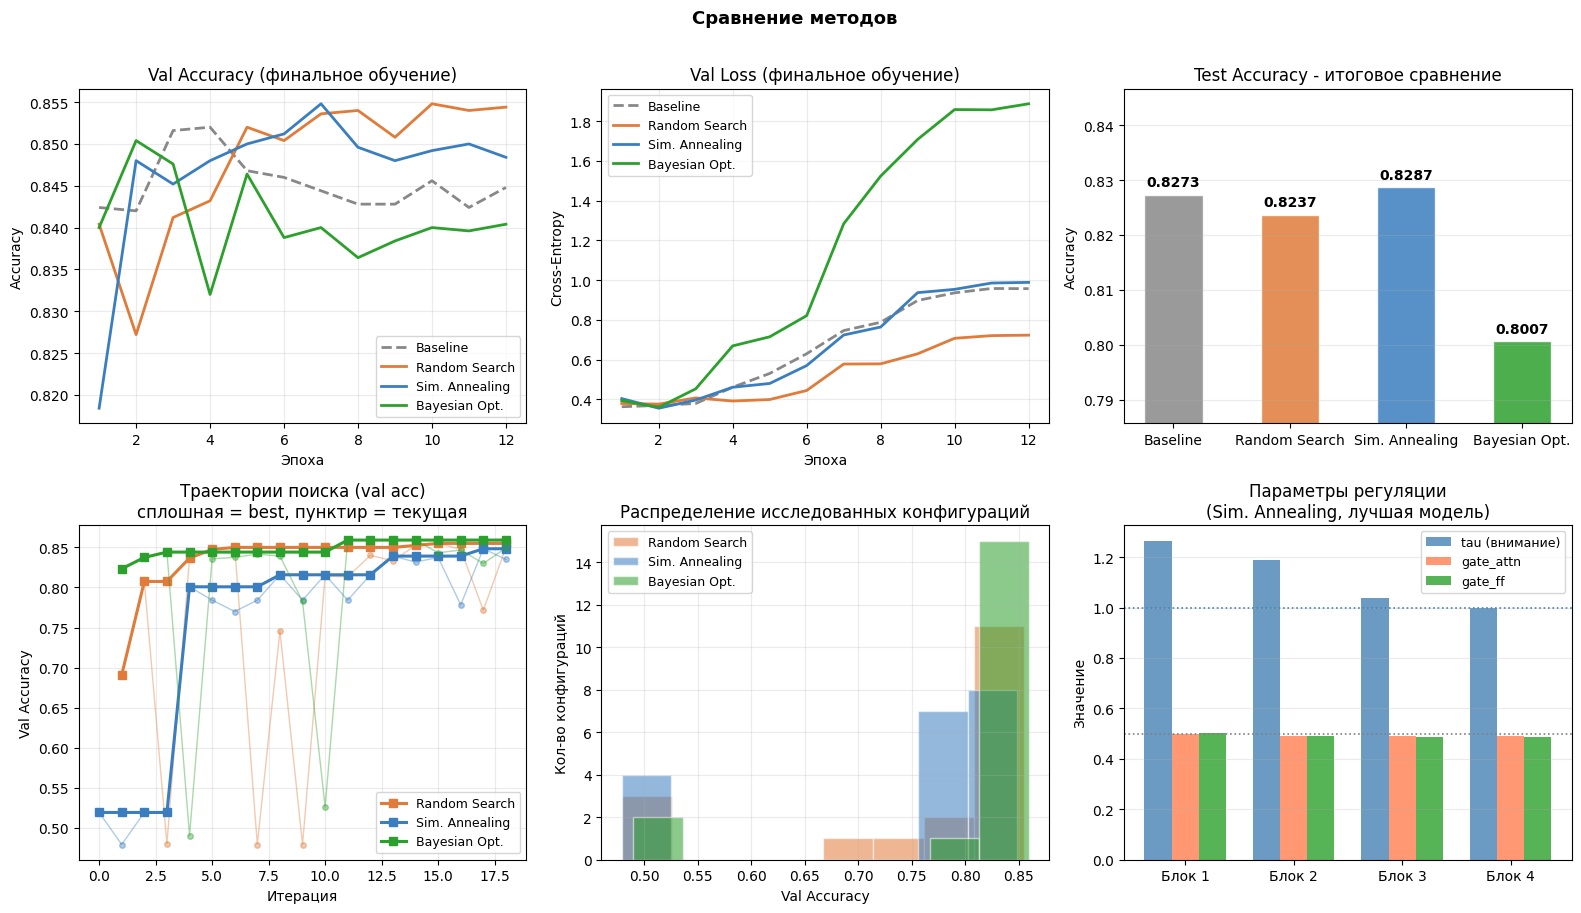

In [27]:
COLORS = {'Baseline':'#888888','Random Search':'#e07b39',
          'Sim. Annealing':'#3a7ebf','Bayesian Opt.':'#2ca02c'}
ep_range = range(1, FINAL_EPOCHS+1)
 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Сравнение методов",
             fontsize=13, fontweight='bold', y=1.01)
 
ax = axes[0,0]
for name, (_, h, _) in results.items():
    ax.plot(ep_range, h['vl'], color=COLORS[name], linewidth=2, label=name,
            linestyle='--' if name=='Baseline' else '-')
ax.set(title="Val Accuracy (финальное обучение)", xlabel="Эпоха", ylabel="Accuracy")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
 
ax = axes[0,1]
for name, (_, h, _) in results.items():
    ax.plot(ep_range, h['vll'], color=COLORS[name], linewidth=2, label=name,
            linestyle='--' if name=='Baseline' else '-')
ax.set(title="Val Loss (финальное обучение)", xlabel="Эпоха", ylabel="Cross-Entropy")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
 
ax = axes[0,2]
names = list(test_accs.keys()); accs = list(test_accs.values())
bars = ax.bar(names, accs, color=[COLORS[n] for n in names], alpha=0.85,
              edgecolor='white', width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_ylim(min(accs)-0.015, max(accs)+0.018)
ax.set(title="Test Accuracy - итоговое сравнение", ylabel="Accuracy")
ax.grid(alpha=0.25, axis='y')
 
ax = axes[1,0]
for hist, name, color in [
    (rs_hist,  'Random Search',  COLORS['Random Search']),
    (sa_hist,  'Sim. Annealing', COLORS['Sim. Annealing']),
    (bo_hist,  'Bayesian Opt.',  COLORS['Bayesian Opt.']),
]:
    iters  = [h['iter'] for h in hist]
    bests  = [h['best'] for h in hist]
    scores = [h['score'] for h in hist]
    ax.plot(iters, scores, 'o-', color=color, alpha=0.4, markersize=4, linewidth=1)
    ax.plot(iters, bests,  's-', color=color, linewidth=2.2, label=name)
ax.set(title="Траектории поиска (val acc)\nсплошная = best, пунктир = текущая", xlabel="Итерация", ylabel="Val Accuracy")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
 
ax = axes[1,1]
for hist, name, color in [
    (rs_hist, 'Random Search',  COLORS['Random Search']),
    (sa_hist, 'Sim. Annealing', COLORS['Sim. Annealing']),
    (bo_hist, 'Bayesian Opt.',  COLORS['Bayesian Opt.']),
]:
    scores = [h['score'] for h in hist]
    ax.hist(scores, bins=8, alpha=0.55, color=color, label=name, edgecolor='white')
ax.set(title="Распределение исследованных конфигураций", xlabel="Val Accuracy", ylabel="Кол-во конфигураций")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
 
best_model_name = max(test_accs, key=test_accs.get)
best_model_obj  = results[best_model_name][0]
 
stats = []
for i, block in enumerate(best_model_obj.blocks):
    tau  = block.attn.tau.detach().cpu()
    stats.append({
        'block': i+1,
        'tau':   tau.mean().item(),
        'ga':    torch.sigmoid(block.ga).mean().item(),
        'gf':    torch.sigmoid(block.gf).mean().item()
    })
 
ax = axes[1,2]
x    = np.arange(len(stats))
w    = 0.25
lbls = [f"Блок {s['block']}" for s in stats]
ax.bar(x-w,   [s['tau'] for s in stats], w, label='tau (внимание)', color='steelblue', alpha=0.8)
ax.bar(x,     [s['ga']  for s in stats], w, label='gate_attn',      color='coral',     alpha=0.8)
ax.bar(x+w,   [s['gf']  for s in stats], w, label='gate_ff',        color='#2ca02c',   alpha=0.8)
ax.axhline(1.0, linestyle=':', color='steelblue', linewidth=1.2)
ax.axhline(0.5, linestyle=':', color='gray',      linewidth=1.2)
ax.set_xticks(x); ax.set_xticklabels(lbls)
ax.set(title=f"Параметры регуляции\n({best_model_name}, лучшая модель)", ylabel="Значение")
ax.legend(fontsize=9); ax.grid(alpha=0.25, axis='y')
 
plt.tight_layout()
plt.show()

## 9. Итоговая таблица

In [28]:
PARAM_NAMES = {'d':'d_model','h':'n_heads','L':'n_layers','drop':'dropout',
               'lr':'lr','bs':'batch_size','ff':'d_ff_mult'}
METHODS = {
    'Baseline':       (DEFAULT, {'val_search': '-',         'val_test': test_accs['Baseline'],  'time': 0}),
    'Random Search':  (rs_best, {'val_search': rs_score,    'val_test': test_accs['Random Search'],  'time': rs_time}),
    'Sim. Annealing': (sa_best, {'val_search': sa_score,    'val_test': test_accs['Sim. Annealing'], 'time': sa_time}),
    'Bayesian Opt.':  (bo_best, {'val_search': bo_score,    'val_test': test_accs['Bayesian Opt.'],  'time': bo_time}),
}
 
print(f"\n{'Параметр':<13}", end="")
for name in METHODS: print(f"  {name:<17}", end="")
print()
print("-" * 80)
 
for pk, pname in PARAM_NAMES.items():
    print(f"{pname:<13}", end="")
    for name, (p, _) in METHODS.items():
        val = p[pk]
        marker = "*" if (name != 'Baseline' and val != DEFAULT[pk]) else " "
        print(f"  {str(val)+marker:<17}", end="")
    print()
 
print("-" * 80)
for metric, label in [('val_search','Val acc (поиск)'), ('val_test','Test accuracy')]:
    print(f"{label:<13}", end="")
    for _, (_, m) in METHODS.items():
        v = m[metric]
        print(f"  {(f'{v:.4f}' if isinstance(v,float) else v):<17}", end="")
    print()
 
print(f"{'Время поиска':<13}", end="")
for _, (_, m) in METHODS.items():
    v = m['time']
    print(f"  {(f'{v/60:.1f} мин' if v > 0 else '-'):<17}", end="")
print()


Параметр       Baseline           Random Search      Sim. Annealing     Bayesian Opt.    
--------------------------------------------------------------------------------
d_model        128                96*                96*                256*             
n_heads        4                  8*                 4                  8*               
n_layers       2                  4*                 4*                 3*               
dropout        0.2                0.3*               0.4*               0.3*             
lr             0.0003             0.0008*            0.0008*            0.0008*          
batch_size     64                 64                 32*                32*              
d_ff_mult      4                  2*                 2*                 2*               
--------------------------------------------------------------------------------
Val acc (поиск)  -                  0.8550             0.8483             0.8592           
Test accuracy  0.8273    

**Выводы по результатам эксперимента**

Все три метода поиска нашли конфигурации, которые на этапе поиска превзошли baseline (0.827), однако на финальной стадии картина неодназначна.

**Разрыв между val (поиск) и test accuracy**. Байесовская оптимизация показала лучший результат на поисковой выборке (0.859), но худший на тесте (0.801). Причина видна из таблицы параметров: BO выбрал d_model=256 с 3 слоями, что дало 6.3M параметров против 2M у остальных. Модель переобучилась на маленькой поисковой выборке (4000 примеров), а при финальном обучении на 18000 примерах это переобучение стало ещё заметнее - val loss растёт с эпохи 4 и к концу достигает 1.9 против 0.7-1.0 у конкурентов.

**Simulated Annealing** показал наилучший test accuracy (0.829) и наиболее стабильные кривые обучения. Найденная конфигурация (d=96, L=4, lr=8e-4, dropout=0.4) хорошо балансирует ёмкость модели и регуляризацию.

**Random Search** нашёл почти идентичную архитектуру (d=96, L=4), но с меньшим dropout=0.3, что дало чуть более нестабильное обучение и test accuracy 0.824.

**Параметры регуляции** лучшей модели (SA) подтверждают, что механизм работает: tau отличается от нейтрального значения 1.0 и меняется по блокам (от 1.25 до 1.0), ворота gate_attn и gate_ff стабилизировались около 0.5, причём gate_attn немного выше - модель чуть больше доверяет блокам внимания, чем feed-forward.

**Практический вывод:** при ограниченном количестве итераций и небольшой поисковой выборке SA оказался надёжнее BO. Суррогатная модель Optuna переоптимизировала под шумную оценку на малых данных. Для корректной работы BO нужно либо увеличить поисковую выборку, либо добавить кросс-валидацию.